# Joins & Merges in pandas
In pandas, the primary methods for combining data are `merge()`, `join()` & `concat()`. <br>
The best method to use depends on whether you want to combine based on shared columns (keys), row indices, or simply stack the dataframes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats


## The `pd.merge()` method
The pd.merge() function is the most flexible method, performing SQL-style join operations based on common columns or indices. It is used for combining dataframes where the relationship between rows is based on shared key values. Important params are:<br>
`left` - The first df on the left<br>
`right` - second df on the right<br>
`on` - the common column in both the tables<br>
`how` - type of join to be implemented ((default)inner/ left/ right/ outer/ cross) etc.<br>
`left_on`/ `right_on` - to specify if names of the joining columns are different


**Syntax could be -**<br>
`pd.merge(left=T1df , right= T2df, on="col_name", how= )` OR

`T1df.merge(T2df, on="col_name", how= )` 

>Working on data on various wards of the city of Chicago -- office locations , census, land use 

In [2]:
# Loading the offices & census datasets
offices = pd.read_pickle("./datasets_joins_merges/ward.p")
census= pd.read_pickle("./datasets_joins_merges/census.p")
licenses = pd.read_pickle("./datasets_joins_merges/licenses.p")
zip = pd.read_pickle("./datasets_joins_merges/zip_demo.p")
print(f"offices- {offices.shape} ; census- {census.shape} ; licenses- {licenses.shape}" )

offices- (50, 4) ; census- (50, 6) ; licenses- (10000, 6)


In [3]:
offices.head()

,ward,alderman,address,zip
0,1,"Proco ""Joe"" Moreno",2058 NORTH WESTERN AVENUE,60647
1,2,Brian Hopkins,1400 NORTH ASHLAND AVENUE,60622
2,3,Pat Dowell,5046 SOUTH STATE STREET,60609
3,4,William D. Burns,"435 EAST 35TH STREET, 1ST FLOOR",60616
4,5,Leslie A. Hairston,2325 EAST 71ST STREET,60649


In [4]:
census.head()

,ward,pop_2000,pop_2010,change,address,zip
0,1,52951,56149,6%,2765 WEST SAINT MARY STREET,60647
1,2,54361,55805,3%,WM WASTE MANAGEMENT 1500,60622
2,3,40385,53039,31%,17 EAST 38TH STREET,60653
3,4,51953,54589,5%,31ST ST HARBOR BUILDING LAKEFRONT TRAIL,60653
4,5,55302,51455,-7%,JACKSON PARK LAGOON SOUTH CORNELL DRIVE,60637


Merging the offices with census table using the **common** "ward" column . This will give a unified table that shows ward office locations , the alderman of that ward , along with the population census

In [5]:
offices_census = pd.merge(left=offices , right= census , how="inner" , on="ward")
offices_census.head()

,ward,alderman,address_x,zip_x,pop_2000,pop_2010,change,address_y,zip_y
0,1,"Proco ""Joe"" Moreno",2058 NORTH WESTERN AVENUE,60647,52951,56149,6%,2765 WEST SAINT MARY STREET,60647
1,2,Brian Hopkins,1400 NORTH ASHLAND AVENUE,60622,54361,55805,3%,WM WASTE MANAGEMENT 1500,60622
2,3,Pat Dowell,5046 SOUTH STATE STREET,60609,40385,53039,31%,17 EAST 38TH STREET,60653
3,4,William D. Burns,"435 EAST 35TH STREET, 1ST FLOOR",60616,51953,54589,5%,31ST ST HARBOR BUILDING LAKEFRONT TRAIL,60653
4,5,Leslie A. Hairston,2325 EAST 71ST STREET,60649,55302,51455,-7%,JACKSON PARK LAGOON SOUTH CORNELL DRIVE,60637


Note the repeated columns from both dataframes (address & zip) are suffixed as `_x` & `_y`. 

The `suffixes` param can be passed a tuple containing custom column names. This helps to better distinguish the column names & their origin.

In [6]:
# Using suffixes parameter to add custom suffixes
offices_census1 = pd.merge(left=offices , right= census , how="inner" , on="ward", suffixes=('_ofc','_cns'))
offices_census1.head(3)

,ward,alderman,address_ofc,zip_ofc,pop_2000,pop_2010,change,address_cns,zip_cns
0,1,"Proco ""Joe"" Moreno",2058 NORTH WESTERN AVENUE,60647,52951,56149,6%,2765 WEST SAINT MARY STREET,60647
1,2,Brian Hopkins,1400 NORTH ASHLAND AVENUE,60622,54361,55805,3%,WM WASTE MANAGEMENT 1500,60622
2,3,Pat Dowell,5046 SOUTH STATE STREET,60609,40385,53039,31%,17 EAST 38TH STREET,60653


## Understanding relationships in df
**One-to-one** - every row in df1 is related to only one row in df2. Example: the above `offices_census` join 

**One-to-many** - every row in df1 is related to more than 1 row in df2. Example: the `offices_licenses` join below -- every ward has multiple businesses.<br>So the df1 (offices) rows are repeated for several of the df2 (licenses) rows.

In [7]:
offices_licenses = offices.merge(licenses , on="ward", suffixes=('_ofc', '_lcn'))
offices_licenses.head()

,ward,alderman,address_ofc,zip_ofc,account,aid,business,address_lcn,zip_lcn
0,1,"Proco ""Joe"" Moreno",2058 NORTH WESTERN AVENUE,60647,12024,NaN,DIGILOG ELECTRONICS,1038 N ASHLAND AVE,60622
1,1,"Proco ""Joe"" Moreno",2058 NORTH WESTERN AVENUE,60647,14446,743,EMPTY BOTTLE INC,1035 N WESTERN AVE 1ST,60622
2,1,"Proco ""Joe"" Moreno",2058 NORTH WESTERN AVENUE,60647,14624,775,LITTLE MEL'S HOT DOG,2205 N CALIFORNIA AVE,60647
3,1,"Proco ""Joe"" Moreno",2058 NORTH WESTERN AVENUE,60647,14987,NaN,MR. BROWN'S LOUNGE,2301 W CHICAGO AVE 1ST,60622
4,1,"Proco ""Joe"" Moreno",2058 NORTH WESTERN AVENUE,60647,15642,814,Beat Kitchen,2000-2100 W DIVISION ST,60622


## Merging Multiple tables - 1
The `licenses` & `wards` table to be merged with `zip_demo` table to gain insights on ward-wise median income.

Find median income by alderman.

In [8]:
licenses_ward_zip = licenses.merge(zip , on="zip").merge(offices, on="ward")
licenses_ward_zip.head()

,account,ward,aid,business,address_x,zip_x,income,alderman,address_y,zip_y
0,307071,3,743,REGGIE'S BAR & GRILL,2105 S STATE ST,60616,46340,Pat Dowell,5046 SOUTH STATE STREET,60609
1,10,10,829,HONEYBEERS,13200 S HOUSTON AVE,60633,50164,Susan Sadlowski Garza,10500 SOUTH EWING AVENUE,60617
2,10002,14,775,CELINA DELI,5089 S ARCHER AVE,60632,42335,Edward M. Burke,2650 WEST 51ST STREET,60632
3,10005,12,NaN,KRAFT FOODS NORTH AMERICA,2005 W 43RD ST,60609,33959,George Cardenas,3476 SOUTH ARCHER AVENUE,60608
4,10044,44,638,NEYBOUR'S TAVERN & GRILLE,3651 N SOUTHPORT AVE,60613,79565,Tom Tunney,3223 NORTH SHEFFIELD AVENUE,60657


In [9]:
cta_stats1 = licenses_ward_zip.groupby("alderman").agg(median_income=("income","median") , no_of_biz=("business","count")).round(2)
cta_stats1.head()

,median_income,no_of_biz
alderman,,
Ameya Pawar,66246.0,275
Anthony A. Beale,38206.0,101
Anthony V. Napolitano,82226.0,153
Ariel E. Reyboras,41307.0,186
Brendan Reilly,110215.0,1369


Finding median income & no. of businesses per ward 

In [10]:
cta_stats2 = licenses_ward_zip.groupby("ward").agg(median_income=("income","median") , no_of_biz=("business","count")).round(2).reset_index()
cta_stats2.head()

,ward,median_income,no_of_biz
0,1,87143.0,253
1,10,38417.0,130
2,11,41226.0,201
3,12,33959.0,255
4,13,67045.0,101


Visualizing of businesses for each ward

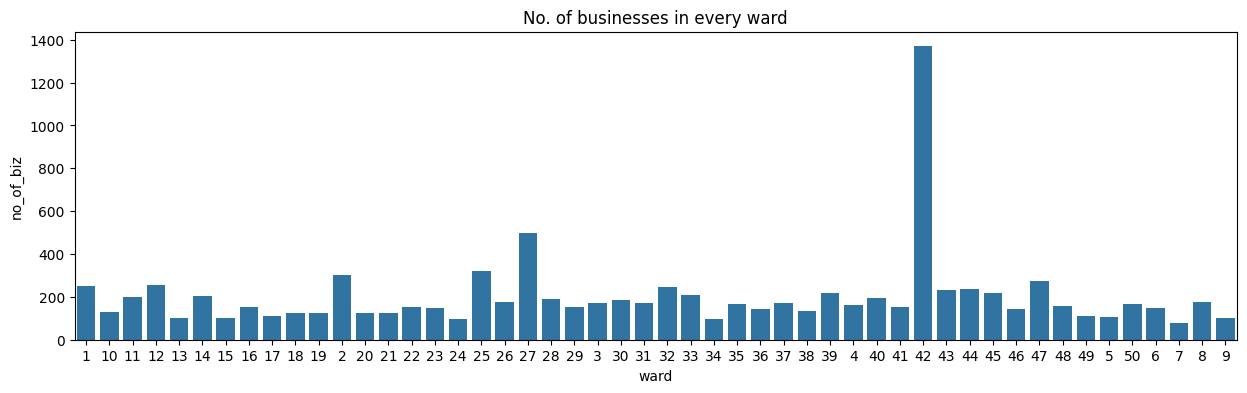

In [11]:
plt.figure(figsize=(15,4))
sns.barplot(data=cta_stats2, x="ward", y="no_of_biz")
plt.title("No. of businesses in every ward")
plt.show()


>- Its observed that ward no. 42 has most amount of businesses. Ward# 27 comes a distant second followed closely by ward# 25.

In [12]:
offices_licenses[offices_licenses["ward"]=="42"].shape

(1371, 9)

## Merging Multiple tables - 2

Find the ridership trends of Chicago public transport system for 2019. Data is available across 3 differnt tables - `cal` `ridership` `stations`

In [13]:
# Loading the CTA ridership dataset
cal = pd.read_pickle("./datasets_joins_merges/cta_calendar.p")
ridership = pd.read_pickle("./datasets_joins_merges/cta_ridership.p")
stations = pd.read_pickle("./datasets_joins_merges/stations.p")

>- Note that the year ,month, day columns from `ridership` & `cal` tables can be recast into datetime objects. 
>- Also, `day_names` can be be created & assigned as `categorical` dtype that'll help in sorting & visualizing.

In [14]:
# importing the datetime library
from datetime import datetime
# assigning week order for day_names column to be created below
weekorder = ["Sunday", "Monday","Tuesday","Wednesday","Thursday","Friday","Saturday"]

In [15]:
# Concatenating year-month-day column to create a unified date column
ridership["unified_date"] =  ridership["year"].astype(str) + "-" + ridership["month"].astype(str) + "-" + ridership["day"].astype(str)
ridership["unified_date"] = pd.to_datetime(ridership["unified_date"])
ridership["day_name"] = ridership["unified_date"].dt.day_name()
ridership["day_name"] = pd.Categorical(ridership["day_name"], categories=weekorder, ordered=True)

ridership.dtypes

station_id              object
year                     int64
month                    int64
day                      int64
rides                    int64
unified_date    datetime64[ns]
day_name              category
dtype: object

In [16]:
print(ridership.head(3))
print(cal.head(3))
print(stations.head(3))

  station_id  year  month  day  rides unified_date   day_name
0      40010  2019      1    1    576   2019-01-01    Tuesday
1      40010  2019      1    2   1457   2019-01-02  Wednesday
2      40010  2019      1    3   1543   2019-01-03   Thursday
   year  month  day        day_type
0  2019      1    1  Sunday/Holiday
1  2019      1    2         Weekday
2  2019      1    3         Weekday
  station_id        station_name                 location
0      40010  Austin-Forest Park  (41.870851, -87.776812)
1      40020         Harlem-Lake  (41.886848, -87.803176)
2      40030        Pulaski-Lake  (41.885412, -87.725404)


In [17]:
# merging all 3 tables in one line
rdshp_cal_stn = ridership.merge(cal, on=["year", "month", "day"]).merge(stations, on="station_id")
rdshp_cal_stn.head()

,station_id,year,month,day,rides,unified_date,day_name,day_type,station_name,location
0,40010,2019,1,1,576,2019-01-01,Tuesday,Sunday/Holiday,Austin-Forest Park,"(41.870851, -87.776812)"
1,40010,2019,1,2,1457,2019-01-02,Wednesday,Weekday,Austin-Forest Park,"(41.870851, -87.776812)"
2,40010,2019,1,3,1543,2019-01-03,Thursday,Weekday,Austin-Forest Park,"(41.870851, -87.776812)"
3,40010,2019,1,4,1621,2019-01-04,Friday,Weekday,Austin-Forest Park,"(41.870851, -87.776812)"
4,40010,2019,1,5,719,2019-01-05,Saturday,Saturday,Austin-Forest Park,"(41.870851, -87.776812)"


The `stations` df has 144 stations with unique IDs, while `cal` is a calender table for 2019. The `ridership` df contains total daily rides for 9 of the 144 stations.

In [18]:
# stations["station_id"].nunique()
# rdshp_cal_stn.shape
# cal["year"].value_counts()
ridership["station_id"].nunique()

9

In [19]:
# Find total monthly rides per station (Grouping & aggregation)
cta_gb1 = rdshp_cal_stn.groupby(["station_name","month"])[["rides"]].agg(rides_avg=("rides","mean"),rides_total=("rides","sum")).reset_index()
cta_gb1.head()

,station_name,month,rides_avg,rides_total
0,35th/Archer,1,2041.290323,63280
1,35th/Archer,2,2351.107143,65831
2,35th/Archer,3,2404.838710,74550
3,35th/Archer,4,2497.833333,74935
4,35th/Archer,5,2567.258065,79585


In [20]:
cta_gb1[(cta_gb1["station_name"]=="Lawrence")]

,station_name,month,rides_avg,rides_total
60,Lawrence,1,2417.161290,74932
61,Lawrence,2,2684.607143,75169
62,Lawrence,3,2668.451613,82722
63,Lawrence,4,2654.800000,79644
64,Lawrence,5,2807.774194,87041
65,Lawrence,6,2721.833333,81655
66,Lawrence,7,2646.419355,82039
67,Lawrence,8,2692.129032,83456
68,Lawrence,9,2900.300000,87009
69,Lawrence,10,2834.193548,87860


C:\Users\abhijeet.bhambere\AppData\Local\Temp\ipykernel_24088\2137203444.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(g.get_xticklabels(),rotation=45)


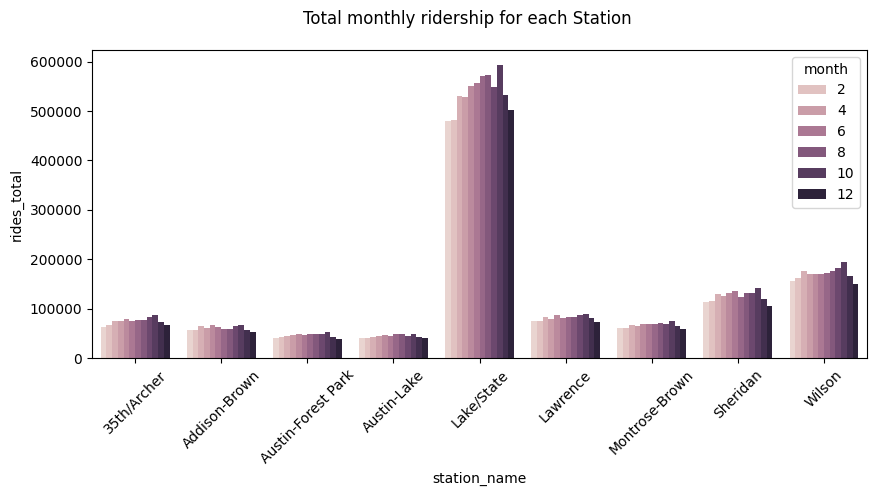

In [21]:
plt.figure(figsize=(10,4))
g = sns.barplot(data=cta_gb1, x="station_name", y="rides_total", hue="month")

g.set_xticklabels(g.get_xticklabels(),rotation=45)

g.figure.suptitle("Total monthly ridership for each Station")
plt.show()

>- Lakes/State station has most ridership - mostly because its a transfer station for several subway lines.
>- Also, October saw highest monthly ridership across all the stations

### Identifying daily ridership trends 

In [22]:
daily_rdshp_gb1 = rdshp_cal_stn.groupby(["station_name","month","day_name"])[["rides"]].sum().reset_index()
daily_rdshp_gb1
daily_rdshp_gb1.head(3)

C:\Users\abhijeet.bhambere\AppData\Local\Temp\ipykernel_24088\1668829030.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily_rdshp_gb1 = rdshp_cal_stn.groupby(["station_name","month","day_name"])[["rides"]].sum().reset_index()


,station_name,month,day_name,rides
0,35th/Archer,1,Sunday,3203
1,35th/Archer,1,Monday,9776
2,35th/Archer,1,Tuesday,11941


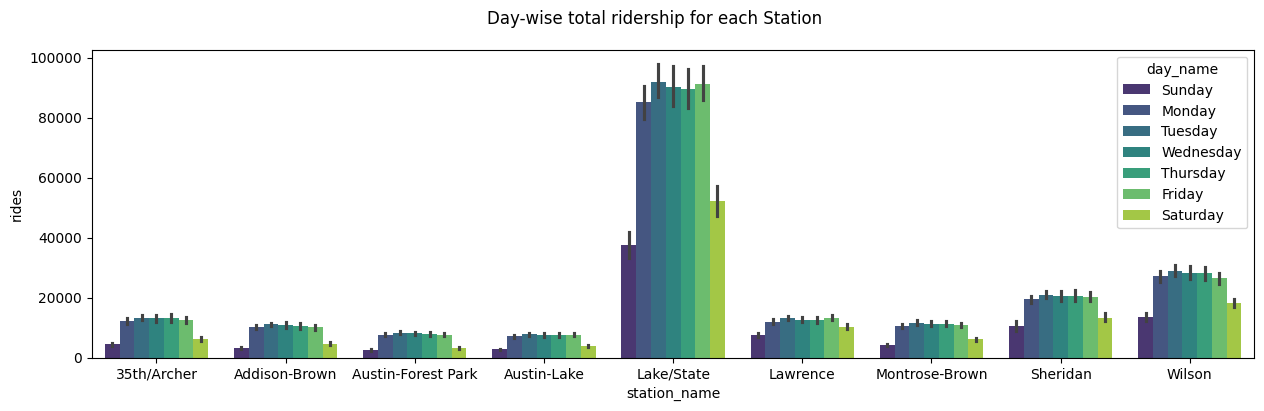

In [23]:
plt.figure(figsize=(15,4))
g = sns.barplot(data=daily_rdshp_gb1, x="station_name",y="rides", hue="day_name", palette="viridis")

# g.set_xticklabels(g.get_xticklabels(),rotation=45)

g.figure.suptitle("Day-wise total ridership for each Station")
plt.show()

>- The weekdays obviously had most ridership with passengers travelling for work.
>- For weekends, the transport system was least used on Sundays as compared to Saturdays 

### Identify trends for the Wilson subway station

In [24]:
# for wilson station
cta_wilson_jul = rdshp_cal_stn[(rdshp_cal_stn["station_name"]=="Wilson") & (rdshp_cal_stn["month"]==7)]
cta_wilson_jul.head()

,station_id,year,month,day,rides,unified_date,day_name,day_type,station_name,location
1641,40540,2019,7,1,6464,2019-07-01,Monday,Weekday,Wilson,"(41.964273, -87.657588)"
1642,40540,2019,7,2,6491,2019-07-02,Tuesday,Weekday,Wilson,"(41.964273, -87.657588)"
1643,40540,2019,7,3,6639,2019-07-03,Wednesday,Weekday,Wilson,"(41.964273, -87.657588)"
1644,40540,2019,7,4,3515,2019-07-04,Thursday,Sunday/Holiday,Wilson,"(41.964273, -87.657588)"
1645,40540,2019,7,5,4794,2019-07-05,Friday,Weekday,Wilson,"(41.964273, -87.657588)"


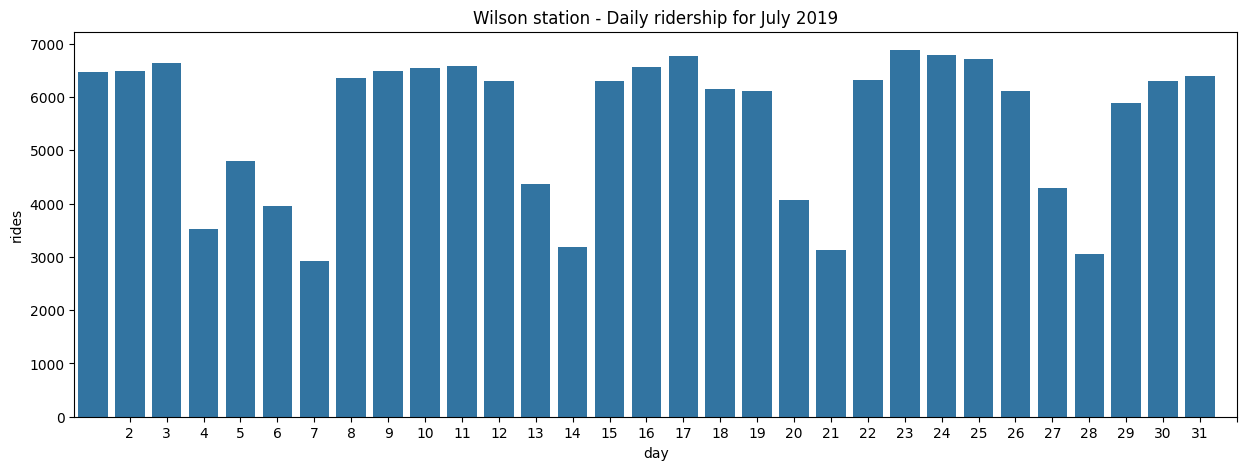

In [25]:
plt.figure(figsize=(15,5))
sns.barplot(data=cta_wilson_jul , x="day", y="rides")
plt.xticks(sorted(cta_wilson_jul["day"].unique()))
plt.title("Wilson station - Daily ridership for July 2019")
plt.show()

In [26]:
cta_pvt1 = pd.pivot_table(data=rdshp_cal_stn, index="month", columns="station_name", values="rides", aggfunc=["sum"]).round(2)
cta_pvt1

sum                                               \
station_name 35th/Archer Addison-Brown Austin-Forest Park Austin-Lake   
month                                                                   
1                  63280         55483              40799       40353   
2                  65831         56726              42096       39555   
3                  74550         64935              44146       43153   
4                  74935         60851              46858       43474   
5                  79585         67114              48136       45997   
6                  74129         61666              45723       44998   
7                  76951         57466              47627       47633   
8                  77527         59339              47617       48337   
9                  82115         64042              47986       45207   
10                 86984         66094              51902       48289   
11                 73498         57200              42042       41386   
12                 66907         53353              38601       39782   

                                                                  
station_name Lake/State Lawrence Montrose-Brown Sheridan  Wilson  
month                                                             
1                480049    74932          60177   113423  155619  
2                481530    75169          60587   115003  161834  
3                530400    82722          66295   130379  175740  
4                528643    79644          65268   124814  169374  
5                551602    87041          69149   130874  170536  
6                557473    81655          67631   135411  170459  
7                570382    82039          68393   124307  172485  
8                572898    83456          70148   130909  175620  
9                548715    87009          67951   132216  182279  
10               594404    87860          74451   142046  194515  
11               532140    81357          64549   119028  165389  
12               502603    72512          58967   105454  149537

In [27]:
print(cta_pvt1.loc[7,('sum','Wilson')])

172485


________________
## Other join types
**Using other types of joins &  analyzing trends in the Movies database -**

`movies` - info on movies like title, popularity, release date etc.<br>
    The `release_date` column to be convered to datetime object & `popularity` rounded to 2 decimal places.

`taglines` - contains taglines for movies. Has fewer rows than `movies` & both are linked by the `id` column.

`financials` - contains budget used & revenue generated for each movie `id`. Note this table also contains lesser row than movies df

`movies_to_genres` - details the genre(s) type of given movie. Note that a single movie could belong to multiple genres.

`sequels` - links movie IDs to each other if they have a sequel. 

`crews` - contains the name of crew members associated with a movie (id)

`casts` - contains the names of cast members associated with a movie (id)

## Left Join

In [28]:
# Loading the movies dataset
movies = pd.read_pickle("./datasets_joins_merges/movies.p")
movies["popularity"] = movies["popularity"].astype(float).round(2)
movies["release_date"] = pd.to_datetime( movies["release_date"])

# Loading the taglines dataframe
taglines = pd.read_pickle("./datasets_joins_merges/taglines.p")

# Loading financial data
financials = pd.read_pickle("./datasets_joins_merges/financials.p")

# loading the crews dataset
crews = pd.read_pickle("./datasets_joins_merges/crews.p")

# loading the crews dataset
cast = pd.read_pickle("./datasets_joins_merges/casts.p")

In [29]:
print(f"movies - {movies.shape} ; taglines - {taglines.shape}")

movies - (4803, 4) ; taglines - (3955, 2)


>Notice the `taglines` df has lesser rows compared to `movies` df.<br>

The "tagline" column will show NaN for those id's in `movies` df for which no tagline is present in the `taglines` df

In [30]:
movies_taglines = movies.merge(taglines, on="id" , how="left", )
movies_taglines.head()

,id,title,popularity,release_date,tagline
0,257,Oliver Twist,20.42,2005-09-23,NaN
1,14290,Better Luck Tomorrow,3.88,2002-01-12,Never underestimate an overachiever.
2,38365,Grown Ups,38.86,2010-06-24,Boys will be boys. . . some longer than others.
3,9672,Infamous,3.68,2006-11-16,There's more to the story than you know
4,12819,Alpha and Omega,12.30,2010-09-17,A Pawsome 3D Adventure


In [31]:
# For example, we see that calling for movie ID# 257 returns an empty df - hence confirming on the Left join
taglines[taglines["id"]==257]

,id,tagline


>**The resulting join will have ALL columns from the Left df (movies).** From the right df (taglines),the resulting table shows  movies with matched ID columns but shows NaN values where no corresponding ID was matched.

The resultant table retains the same no. of rows from the left df (movies df) while pulling data from the right df(taglines).

#### Movie financials - Plotting movies with top10 movies with the most & least ROI.
After merging the table, the "popularity" column can be mapped to distinct categories after studying the value distribution.

In [32]:
# Merging movines info with their respective financials
movie_financials = movies.merge(financials, on="id" , how="left")
print(f"movies- {movies.shape} , financials- {financials.shape},\nmovie_financials- {movie_financials.shape}")


movies- (4803, 4) , financials- (3229, 3),
movie_financials- (4803, 6)


##### EDA objective #1: 
1. Examining the "popularity" column, it seems to be heavily right-skewed -- with some movies having a very high popularity score .

- Dividing the score into 5 distinct categories will allow clearer visualizations.
- Studying the statistics of this column (using `.describe` method), we can see that 75% of values (i.e. movies) have score below 30. 
- Applying the `pd.cut()` method would split the values into score ranges having equal intervals.<br>But that'll put 75% of the movies in low popularity - this is not intended!
- So, applying  `pd.qcut` method is the correct approach to split the values based on quantiles of the fullscore range.<br>This will ensure an almost equal distribution of the categories.

In [33]:
movie_financials["popularity"].describe()

count    4803.000000
mean       21.492292
std        31.816674
min         0.000000
25%         4.670000
50%        12.920000
75%        28.315000
max       875.580000
Name: popularity, dtype: float64

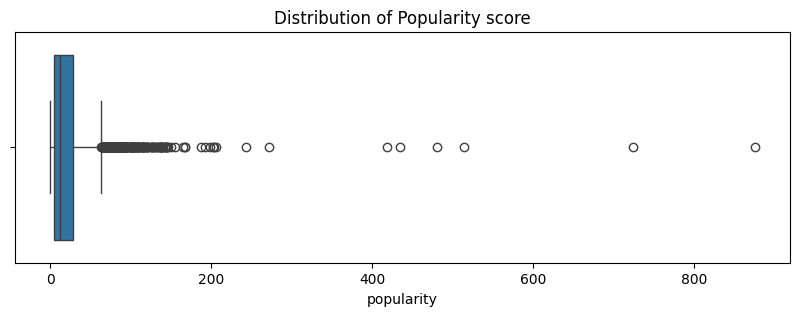

In [34]:
plt.figure(figsize=(10,3))
sns.boxplot(data= movie_financials, x="popularity")
plt.title("Distribution of Popularity score")
plt.show()

In [35]:
# Creating a new column for categories based on popularity score
movie_financials["popularity_cat"] = pd.qcut(movie_financials["popularity"]\
                                        ,q=5,labels=["Very Low", "Low", "Medium", "High", "Very High"])


movie_financials.head()

,id,title,popularity,release_date,budget,revenue,popularity_cat
0,257,Oliver Twist,20.42,2005-09-23,50000000.0,42093706.0,High
1,14290,Better Luck Tomorrow,3.88,2002-01-12,NaN,NaN,Low
2,38365,Grown Ups,38.86,2010-06-24,80000000.0,271430189.0,Very High
3,9672,Infamous,3.68,2006-11-16,13000000.0,1151330.0,Low
4,12819,Alpha and Omega,12.30,2010-09-17,20000000.0,39300000.0,Medium


In [36]:
movie_financials["popularity_cat"].dtype

CategoricalDtype(categories=['Very Low', 'Low', 'Medium', 'High', 'Very High'], ordered=True, categories_dtype=object)

##### EDA objective #2:
2. Examining the dataset with regards to financials 

- we'll drop rows with no financial data available
- Identifying 10 movies with the highest & lowest ROIs each
- Correlation with movie ROI & Popularity score?

In [37]:
# dropping rows with no revenue/ budget details available
movie_financials.dropna(subset=["budget", "revenue"], inplace=True)
movie_financials.head()

,id,title,popularity,release_date,budget,revenue,popularity_cat
0,257,Oliver Twist,20.42,2005-09-23,50000000.0,42093706.0,High
2,38365,Grown Ups,38.86,2010-06-24,80000000.0,271430189.0,Very High
3,9672,Infamous,3.68,2006-11-16,13000000.0,1151330.0,Low
4,12819,Alpha and Omega,12.30,2010-09-17,20000000.0,39300000.0,Medium
5,49529,John Carter,43.93,2012-03-07,260000000.0,284139100.0,Very High


In [38]:
# After dropping NaN revenue & budget rows- 
print(movie_financials.shape)
movie_financials["budget"].isna().sum()

(3229, 7)


np.int64(0)

Adding ROI column

In [39]:
movie_financials["ROI"] = movie_financials["revenue"] - movie_financials["budget"]
movie_financials.head()

,id,title,popularity,release_date,budget,revenue,popularity_cat,ROI
0,257,Oliver Twist,20.42,2005-09-23,50000000.0,42093706.0,High,-7906294.0
2,38365,Grown Ups,38.86,2010-06-24,80000000.0,271430189.0,Very High,191430189.0
3,9672,Infamous,3.68,2006-11-16,13000000.0,1151330.0,Low,-11848670.0
4,12819,Alpha and Omega,12.30,2010-09-17,20000000.0,39300000.0,Medium,19300000.0
5,49529,John Carter,43.93,2012-03-07,260000000.0,284139100.0,Very High,24139100.0


In [40]:
movie_financials["popularity_cat"].value_counts()

popularity_cat
Very High    947
High         875
Medium       705
Low          491
Very Low     211
Name: count, dtype: int64

In [41]:
least_roi_films = movie_financials.sort_values("ROI", ascending=True).head(10)
least_roi_films

,id,title,popularity,release_date,budget,revenue,popularity_cat,ROI
597,57201,The Lone Ranger,49.05,2013-07-03,255000000.0,89289910.0,Very High,-165710090.0
307,10733,The Alamo,10.66,2004-04-07,145000000.0,25819961.0,Medium,-119180039.0
2258,50321,Mars Needs Moms,12.36,2011-03-09,150000000.0,38992758.0,Medium,-111007242.0
4777,1911,The 13th Warrior,27.22,1999-08-27,160000000.0,61698899.0,High,-98301101.0
2720,11692,The Adventures of Pluto Nash,12.09,2002-08-15,100000000.0,7103973.0,Medium,-92896027.0
1796,19,Metropolis,32.35,1927-01-10,92620000.0,650422.0,High,-91969578.0
87,1408,Cutthroat Island,7.03,1995-12-22,98000000.0,10017322.0,Low,-87982678.0
1704,11619,Flushed Away,22.55,2006-10-22,149000000.0,64459316.0,High,-84540684.0
2035,6972,Australia,28.84,2008-11-18,130000000.0,49554002.0,High,-80445998.0
1900,24113,Town & Country,1.00,2001-04-27,90000000.0,10372291.0,Very Low,-79627709.0


In [42]:
most_roi_films = movie_financials.sort_values("ROI", ascending=False).head(10)
most_roi_films

,id,title,popularity,release_date,budget,revenue,popularity_cat,ROI
30,19995,Avatar,150.44,2009-12-10,237000000.0,2.787965e+09,Very High,2.550965e+09
3693,597,Titanic,100.03,1997-11-18,200000000.0,1.845034e+09,Very High,1.645034e+09
1867,135397,Jurassic World,418.71,2015-06-09,150000000.0,1.513529e+09,Very High,1.363529e+09
1471,168259,Furious 7,102.32,2015-04-01,190000000.0,1.506249e+09,Very High,1.316249e+09
608,24428,The Avengers,144.45,2012-04-25,220000000.0,1.519558e+09,Very High,1.299558e+09
2424,99861,Avengers: Age of Ultron,134.28,2015-04-22,280000000.0,1.405404e+09,Very High,1.125404e+09
1465,109445,Frozen,165.13,2013-11-27,150000000.0,1.274219e+09,Very High,1.124219e+09
4546,211672,Minions,875.58,2015-06-17,74000000.0,1.156731e+09,Very High,1.082731e+09
883,122,The Lord of the Rings: The Return of the King,123.63,2003-12-01,94000000.0,1.118889e+09,Very High,1.024889e+09
3286,68721,Iron Man 3,77.68,2013-04-18,200000000.0,1.215440e+09,Very High,1.015440e+09


#### Making multiple merges
Creating a master df - merging all the 3 tables from the movies dataset

In [43]:
movies.merge(financials, on="id" , how="left").merge(taglines, on="id" , how="left")

,id,title,popularity,release_date,budget,revenue,tagline
0,257,Oliver Twist,20.42,2005-09-23,50000000.0,42093706.0,NaN
1,14290,Better Luck Tomorrow,3.88,2002-01-12,NaN,NaN,Never underestimate an overachiever.
2,38365,Grown Ups,38.86,2010-06-24,80000000.0,271430189.0,Boys will be boys. . . some longer than others.
3,9672,Infamous,3.68,2006-11-16,13000000.0,1151330.0,There's more to the story than you know
4,12819,Alpha and Omega,12.30,2010-09-17,20000000.0,39300000.0,A Pawsome 3D Adventure
...,...,...,...,...,...,...,...
4798,3089,Red River,5.34,1948-08-26,3000000.0,9012000.0,Big as the men who faced this challenge! Bold ...
4799,11934,The Hudsucker Proxy,14.19,1994-03-11,NaN,NaN,They took him for a fall guy... but he threw t...
4800,13807,Exiled,8.49,2006-09-06,NaN,NaN,NaN
4801,73873,Albert Nobbs,7.80,2011-12-21,8000000.0,5634828.0,A man with a secret. A woman with a dream.


In [44]:
movies["popularity"].describe()

count    4803.000000
mean       21.492292
std        31.816674
min         0.000000
25%         4.670000
50%        12.920000
75%        28.315000
max       875.580000
Name: popularity, dtype: float64

## Right Join

WE have the genre table form the movies database. Say we want to fetch details for all TV movies. 

- Performing the Left join & filtering for genre=='TV movie' will yield the required result, but it will involve generating a table of almost 4K rows.
- whereas if Right join is implemented (after filtering for genres=='TV movie'), it will yield a table of only those 8 rows (having genre==TV movie), pulling only those rows from the movies df that match the movie's `id`. This method is much more efficient. 

In [45]:
# loading the genres dataset
genres = pd.read_pickle('./datasets_joins_merges/movie_to_genres.p')
genres.dtypes

movie_id     int64
genre       object
dtype: object

In [46]:
tv = genres[genres["genre"]=="TV Movie"]

In [47]:
# performing a right join -- note the use of left_on & right_on parameters
tv_movie_info = movies.merge(tv, left_on="id", right_on="movie_id", how="right")
tv_movie_info

,id,title,popularity,release_date,movie_id,genre
0,10947,High School Musical,16.54,2006-01-20,10947,TV Movie
1,13187,A Charlie Brown Christmas,8.70,1965-12-09,13187,TV Movie
2,22488,Love's Abiding Joy,1.13,2006-10-06,22488,TV Movie
3,78814,We Have Your Husband,0.10,2011-11-12,78814,TV Movie
4,153397,Restless,0.81,2012-12-07,153397,TV Movie
5,158150,How to Fall in Love,1.92,2012-07-21,158150,TV Movie
6,205321,Sharknado,20.47,2013-07-11,205321,TV Movie
7,231617,"Signed, Sealed, Delivered",1.44,2013-10-13,231617,TV Movie


In [48]:
# Note the result would be same if we interchange the table positions & implement a Left join
tv.merge(movies, left_on="movie_id", right_on="id", how="left")

,movie_id,genre,id,title,popularity,release_date
0,10947,TV Movie,10947,High School Musical,16.54,2006-01-20
1,13187,TV Movie,13187,A Charlie Brown Christmas,8.70,1965-12-09
2,22488,TV Movie,22488,Love's Abiding Joy,1.13,2006-10-06
3,78814,TV Movie,78814,We Have Your Husband,0.10,2011-11-12
4,153397,TV Movie,153397,Restless,0.81,2012-12-07
5,158150,TV Movie,158150,How to Fall in Love,1.92,2012-07-21
6,205321,TV Movie,205321,Sharknado,20.47,2013-07-11
7,231617,TV Movie,231617,"Signed, Sealed, Delivered",1.44,2013-10-13


## Outer Join
Its basically a union of both the dataframes.

## Self Join
Its basically a union of a df with itself to examine relationships within the same dataframe, especially when there’s a recursive or internal relationship.

The `sequels` df is one example , where we'd want to list movie sequels against their prequels.

In [49]:
sequels = pd.read_pickle('./datasets_joins_merges/sequels.p')
sequels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      4803 non-null   Int64 
 1   title   4803 non-null   object
 2   sequel  90 non-null     Int64 
dtypes: Int64(2), object(1)
memory usage: 122.1+ KB


In [50]:
# performing a self join
sequels.merge(sequels, left_on="sequel", right_on="id", suffixes=("_org","_seq"))


,id_org,title_org,sequel_org,id_seq,title_seq,sequel_seq
0,862,Toy Story,863,863,Toy Story 2,10193
1,863,Toy Story 2,10193,10193,Toy Story 3,<NA>
2,675,Harry Potter and the Order of the Phoenix,767,767,Harry Potter and the Half-Blood Prince,<NA>
3,121,The Lord of the Rings: The Two Towers,122,122,The Lord of the Rings: The Return of the King,<NA>
4,120,The Lord of the Rings: The Fellowship of the Ring,121,121,The Lord of the Rings: The Two Towers,122
...,...,...,...,...,...,...
85,76,Before Sunrise,80,80,Before Sunset,132344
86,2292,Clerks,2295,2295,Clerks II,<NA>
87,9367,El Mariachi,8068,8068,Desperado,1428
88,8374,The Boondock Saints,22821,22821,The Boondock Saints II: All Saints Day,<NA>


## Joining by Index
This is useful where dataframes could have row labels as indexes. 

> NOTE: ensure to pass arguments for `left_on` & `right_on` params when implementing right or left joins

Implementing this join on modified dfs of the movies database.

In [51]:
movies1 = movies[:].copy()
movies1.set_index("id", inplace=True)

taglines1 = taglines[:].copy()
taglines1.set_index("id", inplace=True)

genres1 = genres[:].copy()
genres1.set_index("movie_id", inplace=True)

In [52]:
# Inner join on index
movies1.merge(taglines1, on="id", how="left")

,title,popularity,release_date,tagline
id,,,,
257,Oliver Twist,20.42,2005-09-23,NaN
14290,Better Luck Tomorrow,3.88,2002-01-12,Never underestimate an overachiever.
38365,Grown Ups,38.86,2010-06-24,Boys will be boys. . . some longer than others.
9672,Infamous,3.68,2006-11-16,There's more to the story than you know
12819,Alpha and Omega,12.30,2010-09-17,A Pawsome 3D Adventure
...,...,...,...,...
3089,Red River,5.34,1948-08-26,Big as the men who faced this challenge! Bold ...
11934,The Hudsucker Proxy,14.19,1994-03-11,They took him for a fall guy... but he threw t...
13807,Exiled,8.49,2006-09-06,NaN


In [53]:
# Inner join index with different index names
movies1.merge(genres1, left_index=True , right_index=True,  how="right")

,title,popularity,release_date,genre
id,,,,
5,Four Rooms,22.88,1995-12-09,Crime
5,Four Rooms,22.88,1995-12-09,Comedy
11,Star Wars,126.39,1977-05-25,Science Fiction
11,Star Wars,126.39,1977-05-25,Action
11,Star Wars,126.39,1977-05-25,Adventure
...,...,...,...,...
426469,Growing Up Smith,0.71,2017-02-03,Drama
433715,8 Days,0.02,2014-06-15,Thriller
433715,8 Days,0.02,2014-06-15,Drama


In [54]:
movies1.merge(genres1, left_index=True, right_on="movie_id", how="left")

,movie_id,title,popularity,release_date,genre
257.0,257,Oliver Twist,20.42,2005-09-23,Crime
257.0,257,Oliver Twist,20.42,2005-09-23,Drama
257.0,257,Oliver Twist,20.42,2005-09-23,Family
14290.0,14290,Better Luck Tomorrow,3.88,2002-01-12,Crime
14290.0,14290,Better Luck Tomorrow,3.88,2002-01-12,Drama
...,...,...,...,...,...
13807.0,13807,Exiled,8.49,2006-09-06,Crime
13807.0,13807,Exiled,8.49,2006-09-06,Action
73873.0,73873,Albert Nobbs,7.80,2011-12-21,Drama
11622.0,11622,Blast from the Past,8.74,1999-02-12,Comedy


## Filtering Joins

> Semi-joins - to find rows in Left df that have matching rows in Right df

> Anti-joins - to find rows in Left df that are not in Right df

### Semi-Join
It is similar to an Inner Join , but only returns matched data from the left table. 

> A semi-join basically means -- _Keep rows from Table A only if they have a match in Table B_.

It does not return any duplicate rows even if one-to-many relationship is present. Inner joint-df makes use of `Ldf.isin(INJ['id'])` to filter from left df

- Create an inner join(INJ) in Ldf & Rdf
- Create a subset INJ ['id']
- Apply `Ldf.isin(INJ['id'])` to filter from left df

In [55]:
financials1 = pd.read_pickle('./datasets_joins_merges/financials.p')
movie_fin = movies.merge(financials1, on="id", how="inner")

In [56]:
# find entries only from movies df that contain financial records
# the .isin() method compares every id in left table to every id in right table
# this creates a subset of movie df that is present in movie_financial df
movies["id"].isin(movie_financials["id"])
# This filters the left df based on rows matched in the right df
movies[movies["id"].isin(movie_financials["id"])]

,id,title,popularity,release_date
0,257,Oliver Twist,20.42,2005-09-23
2,38365,Grown Ups,38.86,2010-06-24
3,9672,Infamous,3.68,2006-11-16
4,12819,Alpha and Omega,12.30,2010-09-17
5,49529,John Carter,43.93,2012-03-07
...,...,...,...,...
4796,869,Planet of the Apes,51.19,2001-07-25
4797,12281,Mean Creek,8.52,2004-01-15
4798,3089,Red River,5.34,1948-08-26
4801,73873,Albert Nobbs,7.80,2011-12-21


> NOTE that result will contain rows only from the Left DataFrame that match in the Right DataFrame

### Anti Join
Its basically to view Left df rows that are missing from Right df

> An anti-join basically means _Keep rows from Table A that DO NOT have a match in Table B._

- create a left join(LFTJ) between Ldf & Rdf with `indicator=True`

- select rows marked 'left_only' & create filter `LFTJ_fil = LFTJ.loc[LFTJ['_merge']=='left_only','id']`

- apply filter to `Ldf[Ldf['id'].isin(LFTJ_fil)]` to get LDf rows missing from RDf 

In [57]:
# Create a left join -- set indicator=True argument adds a column thst tells whether
# the row exists in both columns or left/ right column(s) only.
movie_fin1 = movies.merge(financials, on="id", how="left", indicator=True)
movie_fin1

,id,title,popularity,release_date,budget,revenue,_merge
0,257,Oliver Twist,20.42,2005-09-23,50000000.0,42093706.0,both
1,14290,Better Luck Tomorrow,3.88,2002-01-12,NaN,NaN,left_only
2,38365,Grown Ups,38.86,2010-06-24,80000000.0,271430189.0,both
3,9672,Infamous,3.68,2006-11-16,13000000.0,1151330.0,both
4,12819,Alpha and Omega,12.30,2010-09-17,20000000.0,39300000.0,both
...,...,...,...,...,...,...,...
4798,3089,Red River,5.34,1948-08-26,3000000.0,9012000.0,both
4799,11934,The Hudsucker Proxy,14.19,1994-03-11,NaN,NaN,left_only
4800,13807,Exiled,8.49,2006-09-06,NaN,NaN,left_only
4801,73873,Albert Nobbs,7.80,2011-12-21,8000000.0,5634828.0,both


In [58]:
movie_fin1["_merge"].value_counts()

_merge
both          3229
left_only     1574
right_only       0
Name: count, dtype: int64

In [59]:
# Filter only the rows with merge indicated as left_only
movie_fin1_filter = movie_fin1.loc[movie_fin1["_merge"]=="left_only","id"]

# This only gives left df rows that are NOT in right df
movies[movies["id"].isin(movie_fin1_filter)]

,id,title,popularity,release_date
1,14290,Better Luck Tomorrow,3.88,2002-01-12
7,13785,Best in Show,10.98,2000-09-19
9,18841,The Lost Skeleton of Cadavra,1.68,2001-09-12
11,158752,Escape from Tomorrow,1.35,2013-10-11
15,16186,Diary of a Mad Black Woman,3.78,2005-02-25
...,...,...,...,...
4783,17334,The Other End of the Line,3.39,2008-10-29
4788,25189,The Mirror Has Two Faces,3.84,1996-11-15
4793,198370,Mutual Friends,0.14,2014-04-15
4799,11934,The Hudsucker Proxy,14.19,1994-03-11


In [60]:
# Checking the result -- one such row from left df (movies) in above result will not appear in right df (financials)
financials[financials["id"]==14290]

,id,budget,revenue


> Semi-joins - to find rows in Left df that have matching rows in Right df

> Anti-joins - to find rows in Left df that are not in Right df

## Verifying join integrity in
the `validate` parameter is a sanity check that ensures your merge follows a specific relationship type (1:1, 1:m or m:1).

If, while merging two dfs,we expect certain relationship (like 1:1), but the data actually contains duplicates that would cause a 1:many merge.

Then, pandas will raise a `MergeError` instead of producing unexpected results.

> The validation logic applies to whatever is being used as the "key" for the merge, regardless of whether that key is a column or an index.

It prevents "data explosion," where accidental duplicates in your join keys cause the resulting DataFrame to have far more rows than you intended

In [61]:
movies.merge(cast, left_on="id", right_on="movie_id", how="inner", validate="one_to_many", suffixes=("_m","_c"))

,id_m,title,popularity,release_date,movie_id,cast_id,character,gender,id_c,name
0,257,Oliver Twist,20.42,2005-09-23,257,1,Oliver Twist,2,3542,Barney Clark
1,257,Oliver Twist,20.42,2005-09-23,257,2,Fagin,2,2282,Ben Kingsley
2,257,Oliver Twist,20.42,2005-09-23,257,3,Bill Sikes,2,3543,Jamie Foreman
3,257,Oliver Twist,20.42,2005-09-23,257,4,The Artful Dodger,2,3544,Harry Eden
4,257,Oliver Twist,20.42,2005-09-23,257,5,Mr. Brownlow,2,3545,Edward Hardwicke
...,...,...,...,...,...,...,...,...,...,...
106252,11622,Blast from the Past,8.74,1999-02-12,11622,30,Jerry,2,172734,Don Yesso
106253,11622,Blast from the Past,8.74,1999-02-12,11622,31,Betty,1,1178622,Cynthia Mace
106254,11622,Blast from the Past,8.74,1999-02-12,11622,32,Hotel Desk Clerk,2,166617,Rod Britt
106255,11622,Blast from the Past,8.74,1999-02-12,11622,33,Bob,2,1349629,Harry S. Murphy


## `pd.concat()` method
TO basically stack dataframes on top of each other or besides each other.

Use `ignore_index` param to reset the index to 0. Use `keys` param to add heirarchical indexing -- this will result in a multi-indexed df.

`join` param enables control on type of join used to merge the columns. Its default is 'outer' - hence all columns are included from all the dfs.

`axis` param controls whether merge is vertically stacked (default 0) or along horizontally

In [62]:
# Creating sample dataframes from movies df
movie_con1 = movies.loc[0:3,:].copy()
movie_con2 = movies.loc[10:12,:].copy()
movie_con3 = movies.loc[30:33,:].copy()

In [63]:
# concatenating the 3 dataframes
pd.concat([movie_con1, movie_con2, movie_con3], ignore_index=True)

,id,title,popularity,release_date
0,257,Oliver Twist,20.42,2005-09-23
1,14290,Better Luck Tomorrow,3.88,2002-01-12
2,38365,Grown Ups,38.86,2010-06-24
3,9672,Infamous,3.68,2006-11-16
4,76757,Jupiter Ascending,85.37,2015-02-04
5,158752,Escape from Tomorrow,1.35,2013-10-11
6,10956,Joe Dirt,15.98,2001-04-10
7,19995,Avatar,150.44,2009-12-10
8,85350,Boyhood,43.40,2014-06-05
9,27205,Inception,167.58,2010-07-14


In [64]:
# Adding multi-indexing to the concatenated result 
pd.concat([movie_con1, movie_con2, movie_con3], ignore_index=False, keys=["A","B","C"])

id                 title  popularity release_date
A 0      257          Oliver Twist       20.42   2005-09-23
  1    14290  Better Luck Tomorrow        3.88   2002-01-12
  2    38365             Grown Ups       38.86   2010-06-24
  3     9672              Infamous        3.68   2006-11-16
B 10   76757     Jupiter Ascending       85.37   2015-02-04
  11  158752  Escape from Tomorrow        1.35   2013-10-11
  12   10956              Joe Dirt       15.98   2001-04-10
C 30   19995                Avatar      150.44   2009-12-10
  31   85350               Boyhood       43.40   2014-06-05
  32   27205             Inception      167.58   2010-07-14
  33    9437        Kiss the Girls       18.91   1997-10-03

In [65]:
# concatenating horizontally
pd.concat([movie_con1, movie_con2, movie_con3], ignore_index=False, axis=1,keys=["A","B","C"])

A                                                       B  \
         id                 title popularity release_date        id   
0     257.0          Oliver Twist      20.42   2005-09-23       NaN   
1   14290.0  Better Luck Tomorrow       3.88   2002-01-12       NaN   
2   38365.0             Grown Ups      38.86   2010-06-24       NaN   
3    9672.0              Infamous       3.68   2006-11-16       NaN   
10      NaN                   NaN        NaN          NaT   76757.0   
11      NaN                   NaN        NaN          NaT  158752.0   
12      NaN                   NaN        NaN          NaT   10956.0   
30      NaN                   NaN        NaN          NaT       NaN   
31      NaN                   NaN        NaN          NaT       NaN   
32      NaN                   NaN        NaN          NaT       NaN   
33      NaN                   NaN        NaN          NaT       NaN   

                                                        C                  \
                   title popularity release_date       id           title   
0                    NaN        NaN          NaT      NaN             NaN   
1                    NaN        NaN          NaT      NaN             NaN   
2                    NaN        NaN          NaT      NaN             NaN   
3                    NaN        NaN          NaT      NaN             NaN   
10     Jupiter Ascending      85.37   2015-02-04      NaN             NaN   
11  Escape from Tomorrow       1.35   2013-10-11      NaN             NaN   
12              Joe Dirt      15.98   2001-04-10      NaN             NaN   
30                   NaN        NaN          NaT  19995.0          Avatar   
31                   NaN        NaN          NaT  85350.0         Boyhood   
32                   NaN        NaN          NaT  27205.0       Inception   
33                   NaN        NaN          NaT   9437.0  Kiss the Girls   

                            
   popularity release_date  
0         NaN          NaT  
1         NaN          NaT  
2         NaN          NaT  
3         NaN          NaT  
10        NaN          NaT  
11        NaN          NaT  
12        NaN          NaT  
30     150.44   2009-12-10  
31      43.40   2014-06-05  
32     167.58   2010-07-14  
33      18.91   1997-10-03

## Time-series joins
### `pd.merge_ordered()` method
Performs an outer join & the **result is sorted automatically in order of the joining keys**, Default order of sorting is ascending order.

It is specifically designed to fill gaps in ordered data (like time-series) as it merges, using `fill_method` param.

>NOTE: `fill_method` can **only account for 'missing' rows resulting due to join operation itself**. It cannot fill for data that was already missing (NaN) from the original table.   

Using 2 tables subsetted from a main weather df

In [66]:
weather_maindf = pd.read_csv('./datasets_joins_merges/dailyWeather.csv', parse_dates=["date"]).round(2)
weather_maindf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          114 non-null    datetime64[ns]
 1   meantemp      114 non-null    float64       
 2   humidity      114 non-null    float64       
 3   wind_speed    114 non-null    float64       
 4   meanpressure  114 non-null    float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 4.6 KB


In [67]:
# creating 2 tables from main df
weather1 = weather_maindf.iloc[0:10,0:2].copy()
weather2 = weather_maindf.loc[0:9,["date","humidity"]].copy()

In [68]:
# Simulating missing values for some rows
weather1.iloc[2,1] = None
weather2.iloc[5,1] = None

In [69]:
# deleting a day's record from df2
weather1.drop(index=2, axis=1, inplace=True)
weather2.drop(index=5, axis=1, inplace=True)
weather2

,date,humidity
0,2017-01-01,85.87
1,2017-01-02,77.22
2,2017-01-03,81.89
3,2017-01-04,70.05
4,2017-01-05,74.94
6,2017-01-07,95.83
7,2017-01-08,83.53
8,2017-01-09,80.81
9,2017-01-10,71.94


In [70]:
# joining the two dfs on date column -- notice NaN values in both columns
# these dates (rows) are missing from their respective dfs
pd.merge_ordered(left=weather1, right=weather2, on="date")

,date,meantemp,humidity
0,2017-01-01,15.91,85.87
1,2017-01-02,18.50,77.22
2,2017-01-03,NaN,81.89
3,2017-01-04,18.70,70.05
4,2017-01-05,18.39,74.94
5,2017-01-06,19.32,NaN
6,2017-01-07,14.71,95.83
7,2017-01-08,15.68,83.53
8,2017-01-09,14.57,80.81
9,2017-01-10,12.11,71.94


In [71]:
# handling missing values using fill_method (meantemp value for 3rd Jan; humidity for 6th Jan) 
pd.merge_ordered(weather1, weather2, on="date", fill_method="ffill")

,date,meantemp,humidity
0,2017-01-01,15.91,85.87
1,2017-01-02,18.50,77.22
2,2017-01-03,18.50,81.89
3,2017-01-04,18.70,70.05
4,2017-01-05,18.39,74.94
5,2017-01-06,19.32,74.94
6,2017-01-07,14.71,95.83
7,2017-01-08,15.68,83.53
8,2017-01-09,14.57,80.81
9,2017-01-10,12.11,71.94


## `pd.merge_asof()` method
- It implements a **Left join** wherein the left df row is matched with the nearest key value in the right df rather than requiring an exact match. 

- You can specify `direction`='backward' (last record before/at current time), 'forward' (first record after/at current time), or 'nearest' (the absolute closest record).

- NOTE that both dfs **need to be already sorted by the time key** (although `merge_asof()` can be used for merging any other numeric keys as well)

[<u>_More on pandas joins--stackoverflow_</u>](https://stackoverflow.com/questions/53645882/pandas-merging-101) ,  [<u>_ByteByteGo_</u>](https://bytebytego.com/guides/5-functions-to-merge-data-with-pandas/)
